In [ ]:
!pip install torch torchvision matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 137.1/211.5 MB 153.0 MB/s eta 0:00:01
ERROR: Operation cancelled by user


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        x_hat = torch.sigmoid(self.fc2(h))
        return x_hat

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

In [ ]:
def loss_function(x, x_hat, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [ ]:
# Hyperparameters
input_dim = 784
hidden_dim = 400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 50
# Data loader
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Model, optimizer
vae = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)
# Training loop
vae.train()
for epoch in range(epochs):
    train_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, input_dim)
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(x)
        loss = loss_function(x, x_hat, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}")

Epoch 1, Loss: 164.19951433919272
Epoch 2, Loss: 121.41534427083333
Epoch 3, Loss: 114.61310307617188
Epoch 4, Loss: 111.64968590494792
Epoch 5, Loss: 109.96578719075521
Epoch 6, Loss: 108.81544871419271
Epoch 7, Loss: 107.96281977539063
Epoch 8, Loss: 107.28788458658855
Epoch 9, Loss: 106.84445030924479
Epoch 10, Loss: 106.42337150065104
Epoch 11, Loss: 106.07259638671874
Epoch 12, Loss: 105.77889461263021
Epoch 13, Loss: 105.5164579264323
Epoch 14, Loss: 105.29626811523437
Epoch 15, Loss: 105.05009383138021
Epoch 16, Loss: 104.81866391601562
Epoch 17, Loss: 104.71829848632812
Epoch 18, Loss: 104.48277465820313
Epoch 19, Loss: 104.38415888671875
Epoch 20, Loss: 104.23342973632812
Epoch 21, Loss: 104.10484786783854
Epoch 22, Loss: 104.01227208658854
Epoch 23, Loss: 103.84594186197917
Epoch 24, Loss: 103.71150678710937
Epoch 25, Loss: 103.64482937825521
Epoch 26, Loss: 103.53749786783854
Epoch 27, Loss: 103.43710727539063
Epoch 28, Loss: 103.3715291015625
Epoch 29, Loss: 103.28786118164

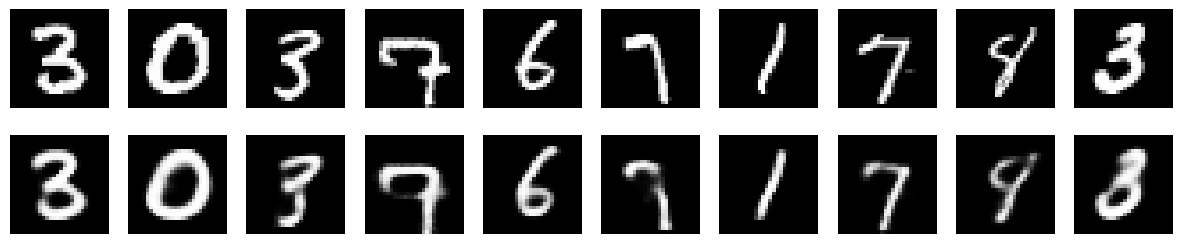

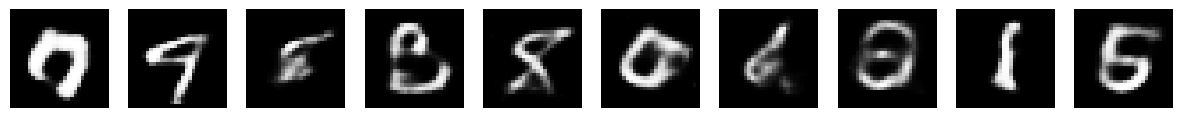

In [ ]:
# visualizing reconstructed outputs
vae.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, input_dim)
    x_hat, _, _ = vae(x)
    x = x.view(-1, 28, 28)
    x_hat = x_hat.view(-1, 28, 28)

    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axs[0, i].imshow(x[i].cpu().numpy(), cmap='gray')
        axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap='gray')
        axs[0, i].axis('off')
        axs[1, i].axis('off')
    plt.show()


#visualizing generated samples
with torch.no_grad():
    z = torch.randn(10, latent_dim)
    sample = vae.decoder(z)
    sample = sample.view(-1, 28, 28)

    fig, axs = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
        axs[i].imshow(sample[i].cpu().numpy(), cmap='gray')
        axs[i].axis('off')
    plt.show()

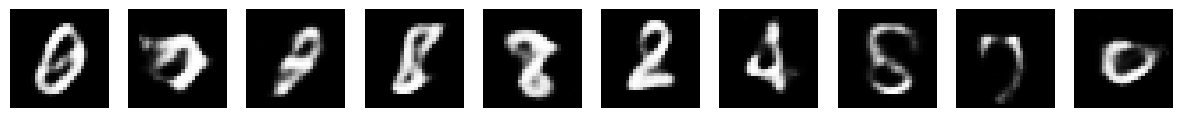

In [ ]:
#visualizing generated samples
with torch.no_grad():
    z = torch.randn(10, latent_dim)
    sample = vae.decoder(z)
    sample = sample.view(-1, 28, 28)

    fig, axs = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
        axs[i].imshow(sample[i].cpu().numpy(), cmap='gray')
        axs[i].axis('off')
    plt.show()

In [ ]:
pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [ ]:
# Data Preprocessing
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.93MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]


In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(28 * 28 + 10, 400)  # Image and one-hot encoded label
        self.fc2_mean = nn.Linear(400, latent_dim)
        self.fc2_logvar = nn.Linear(400, latent_dim)

    def forward(self, x, labels):
        # Concatenate image and label
        x = torch.cat((x.view(-1, 28 * 28), labels), dim=-1)
        x = torch.relu(self.fc1(x))
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar


In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + 10, 400)
        self.fc2 = nn.Linear(400, 28 * 28)

    def forward(self, z, labels):
        # Concatenate z (latent vector) and label
        z = torch.cat((z, labels), dim=-1)
        x = torch.relu(self.fc1(z))
        x = torch.sigmoid(self.fc2(x))
        return x.view(-1, 28, 28)


In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mean, logvar):
        # Sampling from a normal distribution using reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def forward(self, x, labels):
        mean, logvar = self.encoder(x, labels)
        z = self.reparameterize(mean, logvar)
        recon_x = self.decoder(z, labels)
        return recon_x, mean, logvar


In [ ]:
def loss_function(recon_x, x, mean, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x.view(-1, 28 * 28), x.view(-1, 28 * 28), reduction='sum')

    # KL divergence
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # where mu is mean and sigma is std from encoder output
    KL_div = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())

    return BCE + KL_div


In [ ]:
# Set latent dimension
latent_dim = 20

# Instantiate the model, optimizer, and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # One-hot encode labels
        # labels = torch.eye(10)[target].to(device)
        # One-hot encode labels, ensuring torch.eye is on the correct device
        labels = torch.eye(10, device=device)[target].to(device)
        # Forward pass
        recon_batch, mean, logvar = model(data, labels)

        # Compute the loss
        loss = loss_function(recon_batch, data, mean, logvar)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Print training loss after each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss / len(train_loader.dataset)}")


Epoch [1/50], Loss: 163.733348828125
Epoch [2/50], Loss: 119.78999228515625
Epoch [3/50], Loss: 112.52358196614583
Epoch [4/50], Loss: 109.22842542317709
Epoch [5/50], Loss: 107.15675250651041
Epoch [6/50], Loss: 105.70847291666666
Epoch [7/50], Loss: 104.67730555013021
Epoch [8/50], Loss: 103.7978498046875
Epoch [9/50], Loss: 103.138702734375
Epoch [10/50], Loss: 102.54933647460938
Epoch [11/50], Loss: 102.14485563151041
Epoch [12/50], Loss: 101.72311139322916
Epoch [13/50], Loss: 101.3916283203125
Epoch [14/50], Loss: 101.04019918619791
Epoch [15/50], Loss: 100.82395042317708
Epoch [16/50], Loss: 100.54947156575521
Epoch [17/50], Loss: 100.27592864583333
Epoch [18/50], Loss: 100.09237683919271
Epoch [19/50], Loss: 99.95689150390625
Epoch [20/50], Loss: 99.7756037109375
Epoch [21/50], Loss: 99.59801870117188
Epoch [22/50], Loss: 99.44893076171876
Epoch [23/50], Loss: 99.282925390625
Epoch [24/50], Loss: 99.1815903483073
Epoch [25/50], Loss: 99.05410299479166
Epoch [26/50], Loss: 98.89

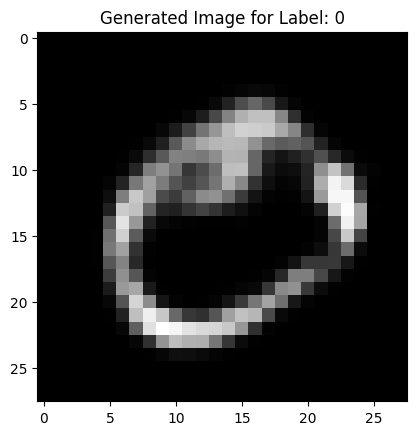

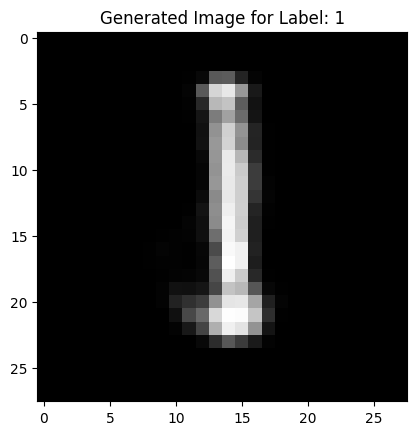

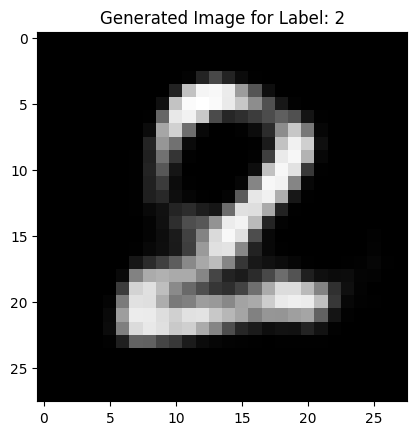

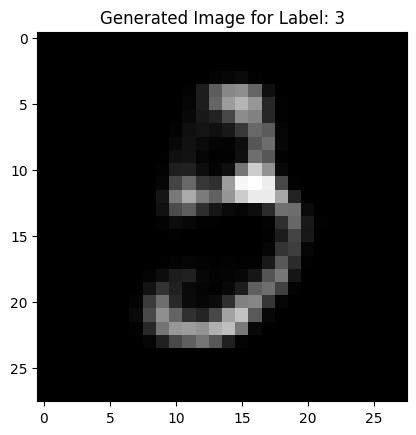

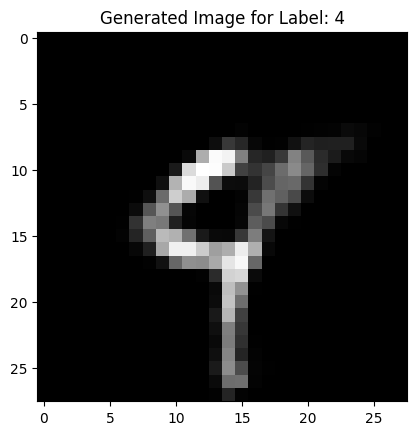

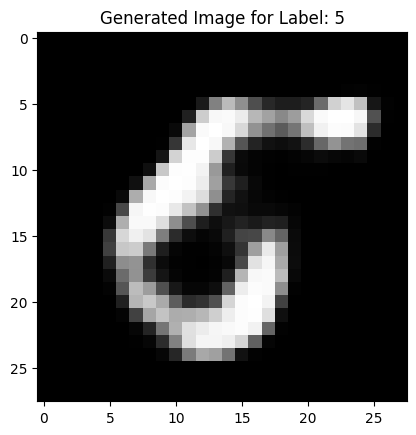

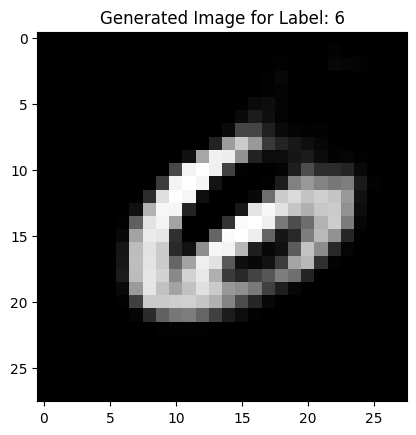

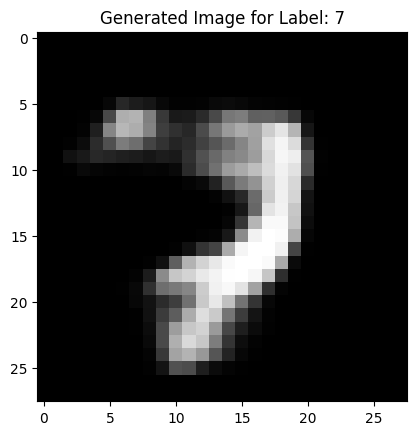

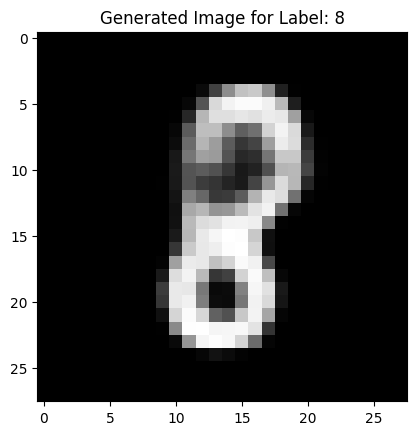

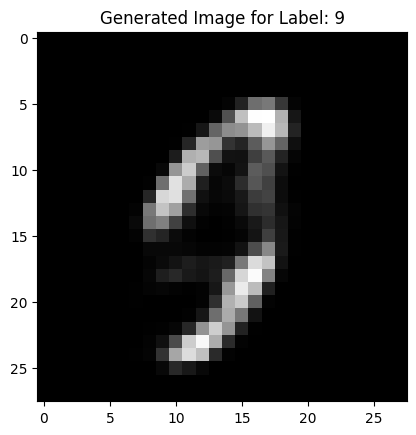

In [ ]:
# Function to generate images using the decoder
def generate_image(model, label, latent_dim=20):
    model.eval()
    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(device)
        label_one_hot = torch.eye(10)[label].unsqueeze(0).to(device)
        generated_image = model.decoder(z, label_one_hot).cpu().numpy().reshape(28, 28)

    plt.imshow(generated_image, cmap='gray')
    plt.title(f"Generated Image for Label: {label}")
    plt.show()

# Generate images for each label
for label in range(10):
    generate_image(model, label)
